In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader

 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), # we are doing resizing this because ResNet expects 224×224
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # mean
                         [0.229, 0.224, 0.225])   # std
])

In [6]:
trainset = torchvision.datasets.CIFAR10(
    root=r"C:\Users\Panshul\Desktop\panshul\download\CIFAR10(CV) DATASET\train",
    train=True,
    download=True,
    transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root = r"C:\Users\Panshul\Desktop\panshul\download\CIFAR10(CV) DATASET\test",
    train = False,
    download = True,
    transform = transform,
)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size = 64, shuffle=False)

In [7]:
# loading pre trained model
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

model = model.to(device)

C:\Users\Panshul\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Panshul\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Panshul/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:02<00:00, 17.5MB/s]


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [9]:
epochs = 2
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(trainloader):.4f}")


Epoch 1/2 - Loss: 0.8327
Epoch 2/2 - Loss: 0.6200


In [10]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 80.27%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6897851..1.907974].


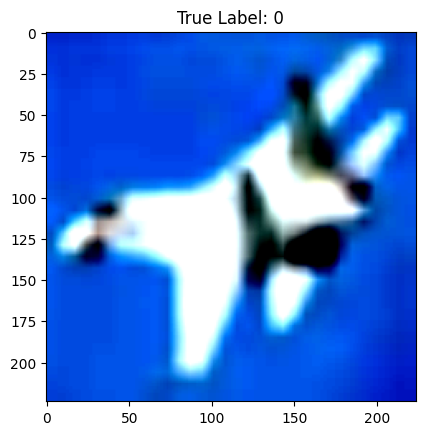

In [11]:
img, label = testset[10]
plt.imshow(img.permute(1, 2, 0))
plt.title(f"True Label: {label}")
plt.show()

# Prepare image for model (add batch dimension)
img_tensor = img.unsqueeze(0).to(device)

In [12]:
activations = {}
def hook_fn(module, input, output):
    activations['layer'] = output


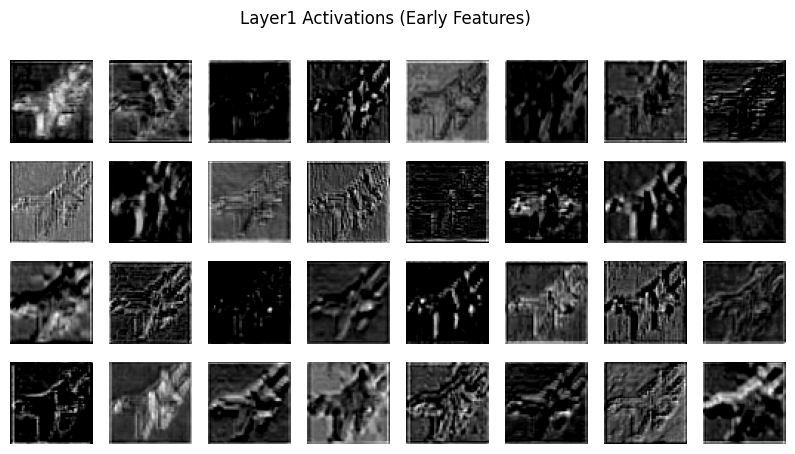

In [13]:
hook = model.layer1.register_forward_hook(hook_fn)
with torch.no_grad():
    _ = model(img_tensor)

# Move activations to CPU for visualization
act = activations['layer'].squeeze().detach().cpu()

fig, axarr = plt.subplots(4, 8, figsize=(10, 5))
for idx in range(32):
    axarr[idx//8, idx%8].imshow(act[idx], cmap='gray')
    axarr[idx//8, idx%8].axis('off')
plt.suptitle("Layer1 Activations (Early Features)")
plt.show()
hook.remove()


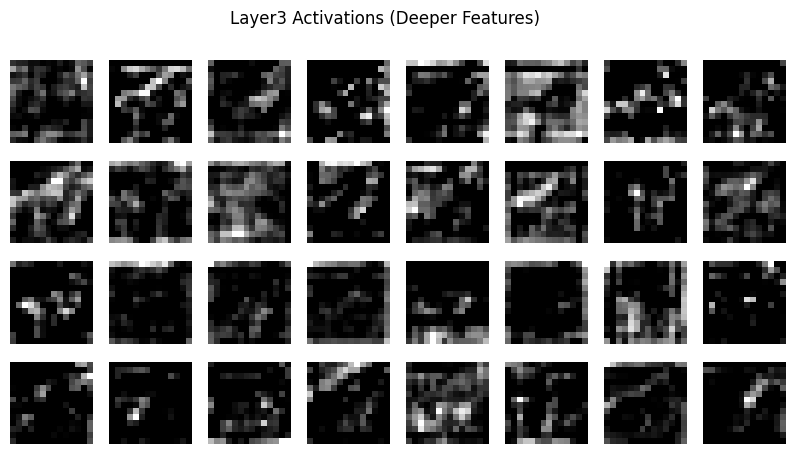

In [14]:
hook = model.layer3.register_forward_hook(hook_fn)
with torch.no_grad():
    _ = model(img_tensor)

act = activations['layer'].squeeze().detach().cpu()

fig, axarr = plt.subplots(4, 8, figsize=(10, 5))
for idx in range(32):
    axarr[idx//8, idx%8].imshow(act[idx], cmap='gray')
    axarr[idx//8, idx%8].axis('off')
plt.suptitle("Layer3 Activations (Deeper Features)")
plt.show()
hook.remove()
